In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [207]:
C = 20
phi = 0.04
I = 92
V_ca = 120
V_k = -84
V_l = -60
g_ca = 4.4
g_k = 8
g_l = 2
V1 = -1.2
V2 = 18
V3 = 2
V4 = 30

In [208]:
def m_inf(v):

    temp = (v - V1) / V2
    
    return 0.5 * (1 + np.tanh(temp))

def w_inf(v):

    temp = (v - V3) / V4
    
    return 0.5 * (1 + np.tanh(temp))

def tau_w(v):
    
    temp = (v - V3) / (2 * V4)
    return np.cosh(temp) ** -1

In [226]:
def fun_vt(data, dt):
    
    v = data[:, 0]
    w = data[:, 1]
    drift = (- g_ca * m_inf(v) * (v - V_ca) - g_k * w * (v - V_k) - g_l * (v - V_l) + I) / C
    v_next = v +  drift * dt
    
    return v_next

def fun_wt(data, dt):
    
    v = data[:, 0]
    w = data[:, 1]
    drift = phi * (w_inf(v) - w) / tau_w(v)
    w_next = w +  drift * dt
    
    return w_next

In [227]:
T = 10
interval = 10000
dt = 0.1
dw = np.sqrt(dt) * np.random.normal(size=(1,))
sigma = 1

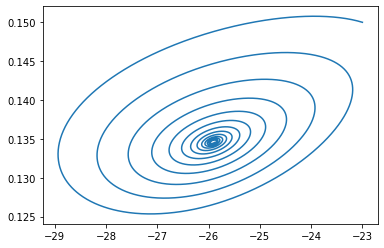

In [278]:
x0 = np.array([[-23, 0.15]])
tra_v = []
tra_w = []
tra_v.append(x0[:, 0])
tra_w.append(x0[:, 1])
# v = x0[:, 0]
# w = x0[:, 1]
data = x0
for i in range(interval):
    v = fun_vt(data, dt)
    w = fun_wt(data, dt)
    data = np.concatenate([v.reshape(-1,1), w.reshape(-1,1)], axis=1)
    tra_v.append(v)
    tra_w.append(w)
plt.plot(np.array(tra_v), np.array(tra_w))

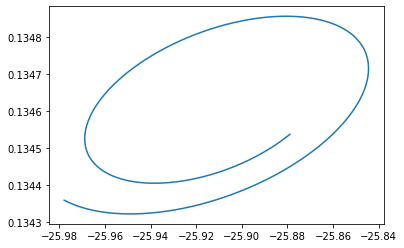

In [291]:
plt.plot(np.array(tra_v)[9000:], np.array(tra_w)[9000:])

In [279]:
data_list = np.concatenate([np.array(tra_v), np.array(tra_w)], axis=1)
data_list.shape

(10001, 2)

In [293]:
data_list[9001:].shape

(1000, 2)

In [290]:
num = 9000
data_list[num: num+5]

array([[-25.9779114 ,   0.13435823],
       [-25.97755468,   0.13435707],
       [-25.97719408,   0.13435594],
       [-25.97682961,   0.13435482],
       [-25.97646131,   0.13435372]])

In [294]:
# np.save('data_steady.npy', data_list[9001:])

In [306]:
data1 = data_list[9001:]
x_mean = data1[:, 0].mean()
y_mean = data1[:, 1].mean()
print(x_mean)
print(type(x_mean))
mu = torch.tensor([x_mean, y_mean])
sigma = torch.eye(2) * 0.1

-25.91222061756733
<class 'numpy.float64'>


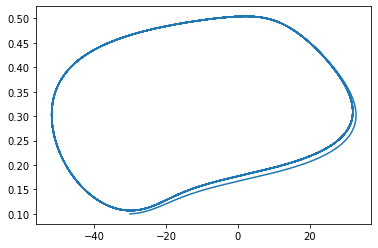

In [295]:
x0 = np.array([[-30, 0.1]])
tra_v = []
tra_w = []
tra_v.append(x0[:, 0])
tra_w.append(x0[:, 1])
data = x0
for i in range(interval):
    v = fun_vt(data, dt)
    w = fun_wt(data, dt)
    data = np.concatenate([v.reshape(-1,1), w.reshape(-1,1)], axis=1)
    tra_v.append(v)
    tra_w.append(w)
    
# plt.plot(np.array(tra_v)[:, 0], np.array(tra_w)[:, 0])
plt.plot(np.array(tra_v), np.array(tra_w))

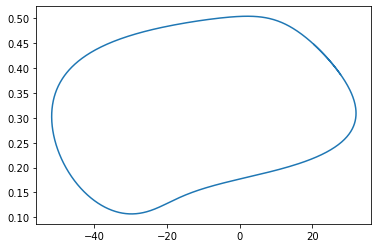

In [296]:
plt.plot(np.array(tra_v)[9000:], np.array(tra_w)[9000:])

In [298]:
data_cycle = np.concatenate([np.array(tra_v), np.array(tra_w)], axis=1)
data_cycle.shape, data_cycle[9001:].shape

((10001, 2), (1000, 2))

In [299]:
# np.save('data_cycle.npy', data_cycle[9001:])

In [55]:
import pylab

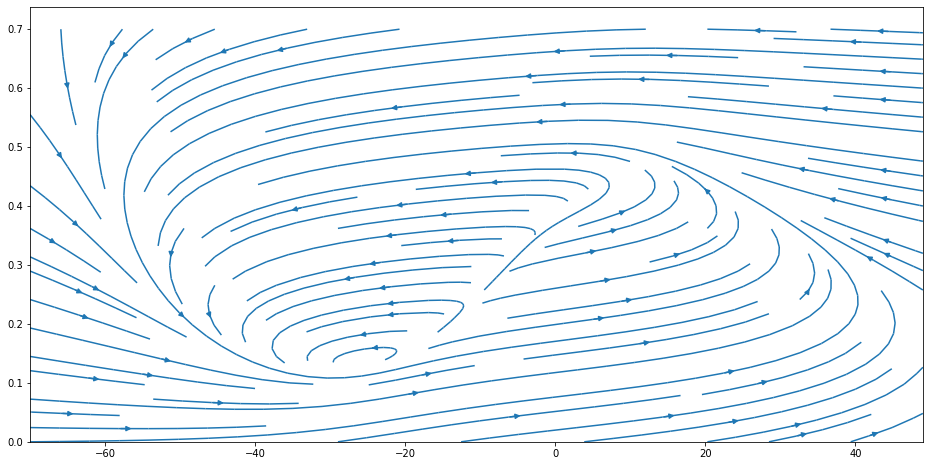

In [65]:
pylab.figure(figsize=(16,8))
x_mesh, y_mesh = pylab.meshgrid(pylab.arange(-70, 50, 1),pylab.arange(0, 0.8, 0.1))
dx_dt = (- g_ca * m_inf(x_mesh) * (x_mesh - V_ca) - g_k * y_mesh * (x_mesh - V_k) - g_l * (x_mesh - V_l) + I) / C
dy_dt = phi * (w_inf(x_mesh) - y_mesh) / tau_w(x_mesh)
# dx_dt = 2*x + 3*y
# dy_dt = 2*x - 3*y
pylab.streamplot(x_mesh,y_mesh,dx_dt,dy_dt)

pylab.show()